In [ ]:
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import statsmodels.api as sm

In [ ]:
df = pd.read_csv("cleaned_final_10k_dataset.csv")
df

,headline,date,section,type,source,text_snippet,full_text,compound_score,pos_score,neg_score,is_after_election
0,Harris attacks Trump over Roe v Wade at first ...,2024-01-23,US news,Politics,The Guardian,Vice-president appeared Tuesday in Virginia wi...,Joe Biden and Kamala Harris kicked off their f...,-0.4404,0.000,0.209,False
1,Biden re-election campaign to put emphasis on ...,2024-01-03,US news,Politics,The Guardian,Biden-Harris camp announces campaign plan that...,"Good morning. Ailing in opinion polls, Joe Bid...",-0.3818,0.000,0.191,False
2,Biden attacks Trump as grave threat to democra...,2024-01-05,US news,Politics,The Guardian,"On eve of January 6 anniversary, US president ...",A day before the third anniversary of the Janu...,-0.8360,0.000,0.497,False
3,Sherrilyn Ifill on a Trump win: ‘We will cease...,2024-01-07,US news,Politics,The Guardian,The longtime civil rights lawyer on the 14th a...,The timing is right for a 14th amendment renai...,0.5859,0.275,0.000,False
4,Icy battle for democracy in Iowa with Trump ex...,2024-01-15,US news,Politics,The Guardian,The first stage of the 2024 election takes pla...,A cold coming we had of it. Icy winds blow acr...,0.2960,0.196,0.134,False
...,...,...,...,...,...,...,...,...,...,...,...
10842,Europe’s Growing Fear: How Trump Might Use U.S...,2025-06-20,Technology,Conflict,New York Times,"To comply with a Trump executive order, Micros...","To comply with a Trump executive order, Micros...",-0.1779,0.223,0.204,True
10843,Israel Attacked Iran’s State TV,2025-06-16,Briefing,Conflict,New York Times,"Also, the suspect in the Minnesota killings co...","Also, the suspect in the Minnesota killings co...",-0.4588,0.000,0.429,True
10844,"Starmer Picks Up Trump’s Papers, and 2 Small P...",2025-06-17,World,Conflict,New York Times,The British prime minister scrambled at Presid...,The British prime minister scrambled at Presid...,0.5719,0.316,0.000,True
10845,A Primary and a Heat Wave,2025-06-25,Briefing,Conflict,New York Times,We’re covering the upset in New York City and ...,We’re covering the upset in New York City and ...,0.0000,0.000,0.000,True


#**Q1 - Does the sentiment of political headlines change significantly before and after election dates?**

In [ ]:
# 1. Prepare Data
q1_df = df[df['type'] == 'Politics'].copy()
q1_df

,headline,date,section,type,source,text_snippet,full_text,compound_score,pos_score,neg_score,is_after_election
0,Harris attacks Trump over Roe v Wade at first ...,2024-01-23,US news,Politics,The Guardian,Vice-president appeared Tuesday in Virginia wi...,Joe Biden and Kamala Harris kicked off their f...,-0.4404,0.000,0.209,False
1,Biden re-election campaign to put emphasis on ...,2024-01-03,US news,Politics,The Guardian,Biden-Harris camp announces campaign plan that...,"Good morning. Ailing in opinion polls, Joe Bid...",-0.3818,0.000,0.191,False
2,Biden attacks Trump as grave threat to democra...,2024-01-05,US news,Politics,The Guardian,"On eve of January 6 anniversary, US president ...",A day before the third anniversary of the Janu...,-0.8360,0.000,0.497,False
3,Sherrilyn Ifill on a Trump win: ‘We will cease...,2024-01-07,US news,Politics,The Guardian,The longtime civil rights lawyer on the 14th a...,The timing is right for a 14th amendment renai...,0.5859,0.275,0.000,False
4,Icy battle for democracy in Iowa with Trump ex...,2024-01-15,US news,Politics,The Guardian,The first stage of the 2024 election takes pla...,A cold coming we had of it. Icy winds blow acr...,0.2960,0.196,0.134,False
...,...,...,...,...,...,...,...,...,...,...,...
10746,"Andrew Schulz, ‘Podcast Bro,’ Might Be America...",2025-06-21,Magazine,Politics,New York Times,The comedian and host has a huge audience and ...,The comedian and host has a huge audience and ...,0.0000,0.000,0.000,True
10747,Suspect in Colorado Attack Was Charged With a ...,2025-06-02,Briefing,Politics,New York Times,"Also, coffee was linked to healthy aging. Here...","Also, coffee was linked to healthy aging. Here...",-0.9231,0.000,0.781,True
10748,How the Transgender Rights Movement Bet on the...,2025-06-19,Magazine,Politics,New York Times,The inside story of the case that could set th...,The inside story of the case that could set th...,0.3182,0.226,0.145,True
10749,Ehud Olmert on Israel’s Catastrophic War in Gaza,2025-06-11,Opinion,Politics,New York Times,The former prime minister of Israel discusses ...,The former prime minister of Israel discusses ...,-0.7964,0.000,0.542,True


In [ ]:
# 3. Calculate Mean and Margin of Error (2 * SE)
stats_q1 = q1_df.groupby('is_after_election')['compound_score'].agg(['mean', 'std', 'count'])

# Calculate Standard Error (SE).
# This helps us estimate how precise our calculated mean is relative to the true population mean.
stats_q1['SE'] = stats_q1['std'] / np.sqrt(stats_q1['count'])

# Calculate the Margin of Error for a 95% confidence interval.
# We multiply SE by 2 (approx Z-score of 1.96) to define the range where the true mean likely falls.
stats_q1['Margin_Error'] = 2 * stats_q1['SE']

stats_q1

,mean,std,count,SE,Margin_Error
is_after_election,,,,,
False,-0.034344,0.350355,2473,0.007045,0.014091
True,-0.054968,0.348163,1701,0.008442,0.016883


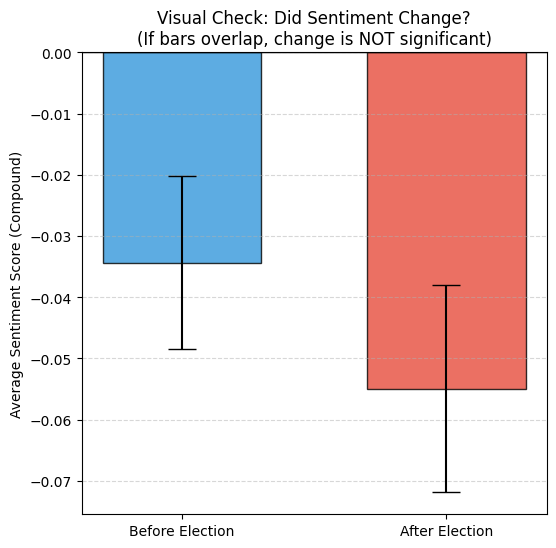

In [ ]:
# 4. Create the Plot
plt.figure(figsize=(6, 6))

# Define Data
means = stats_q1['mean']
errors = stats_q1['Margin_Error']
labels = ['Before Election', 'After Election']
colors = ['#3498db', '#e74c3c'] # Blue vs Red

# Draw Bars with Error Whiskers
plt.bar(labels, means, yerr=errors, capsize=10, color=colors, alpha=0.8, edgecolor='black', width=0.6)

# Add Title and Labels
plt.title('Visual Check: Did Sentiment Change?\n(If bars overlap, change is NOT significant)', fontsize=12)
plt.ylabel('Average Sentiment Score (Compound)')
plt.axhline(0, color='black', linewidth=1) # Zero line
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Show Plot
plt.show()

In [ ]:
print("--- Visual Check Data ---")

# Print the precise numerical ranges for the confidence intervals.
# Format: Mean ± Margin of Error (Lower Bound, Upper Bound)

print(f"Before Range: {means.iloc[0]:.3f} ± {errors.iloc[0]:.3f}  (Low: {means.iloc[0]-errors.iloc[0]:.3f}, High: {means.iloc[0]+errors.iloc[0]:.3f})")
print(f"After Range:  {means.iloc[1]:.3f} ± {errors.iloc[1]:.3f}  (Low: {means.iloc[1]-errors.iloc[1]:.3f}, High: {means.iloc[1]+errors.iloc[1]:.3f})")

# Automatic Conclusion
# Calculate the specific upper and lower bounds for the error bars
high_before = means.iloc[0] + errors.iloc[0]
low_before = means.iloc[0] - errors.iloc[0]
high_after = means.iloc[1] + errors.iloc[1]
low_after = means.iloc[1] - errors.iloc[1]

if (low_before < high_after) and (low_after < high_before):
    print("\nRESULT: The bars OVERLAP.")
    print("CONCLUSION: The change is NOT statistically significant.")
else:
    print("\nRESULT: The bars DO NOT overlap.")
    print("CONCLUSION: The change IS statistically significant.")

--- Visual Check Data ---
Before Range: -0.034 ± 0.014  (Low: -0.048, High: -0.020)
After Range:  -0.055 ± 0.017  (Low: -0.072, High: -0.038)

RESULT: The bars OVERLAP.
CONCLUSION: The change is NOT statistically significant.


#**Q2 - Are news outlets more likely to use negative sentiment words in political coverage compared to economic news?**

In [ ]:
# 2. Filter for Question 2 (Economy vs Politics)

# Filter the main DataFrame to keep only rows where the 'type' is either 'Politics' or 'Economy'.
# .isin(['Politics', 'Economy']): Checks if the value belongs to the specified list.


q2_df = df[df['type'].isin(['Politics', 'Economy'])].copy()
q2_df

,headline,date,section,type,source,text_snippet,full_text,compound_score,pos_score,neg_score,is_after_election
0,Harris attacks Trump over Roe v Wade at first ...,2024-01-23,US news,Politics,The Guardian,Vice-president appeared Tuesday in Virginia wi...,Joe Biden and Kamala Harris kicked off their f...,-0.4404,0.000,0.209,False
1,Biden re-election campaign to put emphasis on ...,2024-01-03,US news,Politics,The Guardian,Biden-Harris camp announces campaign plan that...,"Good morning. Ailing in opinion polls, Joe Bid...",-0.3818,0.000,0.191,False
2,Biden attacks Trump as grave threat to democra...,2024-01-05,US news,Politics,The Guardian,"On eve of January 6 anniversary, US president ...",A day before the third anniversary of the Janu...,-0.8360,0.000,0.497,False
3,Sherrilyn Ifill on a Trump win: ‘We will cease...,2024-01-07,US news,Politics,The Guardian,The longtime civil rights lawyer on the 14th a...,The timing is right for a 14th amendment renai...,0.5859,0.275,0.000,False
4,Icy battle for democracy in Iowa with Trump ex...,2024-01-15,US news,Politics,The Guardian,The first stage of the 2024 election takes pla...,A cold coming we had of it. Icy winds blow acr...,0.2960,0.196,0.134,False
...,...,...,...,...,...,...,...,...,...,...,...
10781,Investors on Edge About a Potential Shadow Fed...,2025-06-26,Business,Economy,New York Times,Traders have moved on a report that President ...,Traders have moved on a report that President ...,0.0000,0.000,0.000,True
10782,13 Gen Z-ers on Whether America’s Best Days Ar...,2025-06-13,Opinion,Economy,New York Times,"The group discusses early adulthood, Donald Tr...","The group discusses early adulthood, Donald Tr...",0.6369,0.296,0.000,True
10783,The China Wild Card,2025-06-23,Business,Economy,New York Times,Beijing is one of Tehran’s most important econ...,Beijing is one of Tehran’s most important econ...,0.0000,0.000,0.000,True
10784,Consumers Are Financing Their Groceries. What ...,2025-06-02,Business,Economy,New York Times,"Increased use of “buy now, pay later” loans ma...","Increased use of “buy now, pay later” loans ma...",0.0000,0.000,0.000,True


In [ ]:
# 3. Calculate Mean and Margin of Error (2 * SE) for Negative Score
stats_q2 = q2_df.groupby('type')['neg_score'].agg(['mean', 'std', 'count'])

# Calculate Standard Error (SE): std / sqrt(n)

stats_q2['SE'] = stats_q2['std'] / np.sqrt(stats_q2['count'])

# Calculate Margin of Error (approx 95% Confidence Interval)

stats_q2['Margin_Error'] = 2 * stats_q2['SE']
stats_q2

,mean,std,count,SE,Margin_Error
type,,,,,
Economy,0.112730,0.134162,2978,0.002458,0.004917
Politics,0.097295,0.137246,4174,0.002124,0.004249


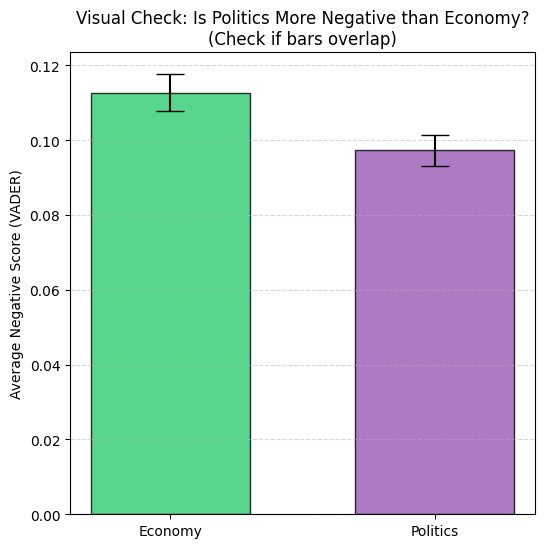

In [ ]:
# 4. Create the Plot
plt.figure(figsize=(6, 6))

# Define Data
means = stats_q2['mean']
errors = stats_q2['Margin_Error']
labels = stats_q2.index # ['Economy', 'Politics']
colors = ['#2ecc71', '#9b59b6'] # Green vs Purple

# Draw Bars with Error Whiskers
plt.bar(labels, means, yerr=errors, capsize=10, color=colors, alpha=0.8, edgecolor='black', width=0.6)

# Add Title and Labels
plt.title('Visual Check: Is Politics More Negative than Economy?\n(Check if bars overlap)', fontsize=12)
plt.ylabel('Average Negative Score (VADER)')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Show Plot
plt.show()

In [ ]:
# --- PRINT THE NUMBERS FOR YOUR REPORT ---
print("--- Visual Check Data ---")


# Extract specific values using .loc[row_label, col_label]
# We need the mean and margin of error for both categories to compare them.


eco_mean = stats_q2.loc['Economy', 'mean']
eco_err = stats_q2.loc['Economy', 'Margin_Error']
pol_mean = stats_q2.loc['Politics', 'mean']
pol_err = stats_q2.loc['Politics', 'Margin_Error']


# Print the precise numerical ranges (Confidence Intervals)

print(f"Economy Range: {eco_mean:.3f} ± {eco_err:.3f}  (Low: {eco_mean-eco_err:.3f}, High: {eco_mean+eco_err:.3f})")
print(f"Politics Range: {pol_mean:.3f} ± {pol_err:.3f}  (Low: {pol_mean-pol_err:.3f}, High: {pol_mean+pol_err:.3f})")

# Automatic Conclusion
# If the Lower Bound of Economy is greater than the Upper Bound of Politics, they are distinct.
if (eco_mean - eco_err) > (pol_mean + pol_err):
    print("\nRESULT: The bars DO NOT overlap.")
    print("CONCLUSION: The difference IS significant.")
    print("INSIGHT: Economy news is actually MORE negative than Politics.")

# If they overlap, we cannot claim one is consistently more negative than the other.
else:
    print("\nRESULT: The bars OVERLAP.")
    print("CONCLUSION: No significant difference.")

--- Visual Check Data ---
Economy Range: 0.113 ± 0.005  (Low: 0.108, High: 0.118)
Politics Range: 0.097 ± 0.004  (Low: 0.093, High: 0.102)

RESULT: The bars DO NOT overlap.
CONCLUSION: The difference IS significant.
INSIGHT: Economy news is actually MORE negative than Politics.


# **Q3 -  Is there a clustering pattern in how different news sources report global conflicts?**

In [ ]:
#Filter the DataFrame to keep only rows where the 'type' is 'Conflict'.
# .dropna(subset=['']): Removes any rows where the text is missing (NaN).
# This is crucial because we cannot analyze topics if there is no text to read.

q3_df = df[df['type'] == 'Conflict'].dropna(subset=['text_snippet']).copy()
q3_df

,headline,date,section,type,source,text_snippet,full_text,compound_score,pos_score,neg_score,is_after_election
299,Russia-Ukraine war live: Russia and Ukraine ex...,2024-01-31,World news,Conflict,The Guardian,Deal to swap around 200 PoWs from each side co...,Here is the summary of the key developments in...,-0.9022,0.000,0.526,False
300,Russia-Ukraine war: Ukraine says it hit Russia...,2024-01-04,World news,Conflict,The Guardian,Russian defence ministry says it shot down 10 ...,It is just after 6pm in Kyiv. Here is a summar...,-0.7906,0.000,0.269,False
301,Russia and Ukraine trade accusations over fata...,2024-01-25,World news,Conflict,The Guardian,Moscow had accused Kyiv of downing plane it sa...,Russia and Ukraine have traded accusations ove...,-0.8176,0.000,0.548,False
302,Russia-Ukraine war: No survivors after militar...,2024-01-24,World news,Conflict,The Guardian,Russia claims aircraft was carrying 65 Ukraini...,This blog is now closing. Below is a roundup o...,-0.7269,0.000,0.253,False
303,Russia-Ukraine war: France and Ukraine to ‘sca...,2024-01-13,World news,Conflict,The Guardian,The announcement comes after the UK also confi...,Here is a round-up of the key events today. Mo...,-0.5423,0.086,0.239,False
...,...,...,...,...,...,...,...,...,...,...,...
10842,Europe’s Growing Fear: How Trump Might Use U.S...,2025-06-20,Technology,Conflict,New York Times,"To comply with a Trump executive order, Micros...","To comply with a Trump executive order, Micros...",-0.1779,0.223,0.204,True
10843,Israel Attacked Iran’s State TV,2025-06-16,Briefing,Conflict,New York Times,"Also, the suspect in the Minnesota killings co...","Also, the suspect in the Minnesota killings co...",-0.4588,0.000,0.429,True
10844,"Starmer Picks Up Trump’s Papers, and 2 Small P...",2025-06-17,World,Conflict,New York Times,The British prime minister scrambled at Presid...,The British prime minister scrambled at Presid...,0.5719,0.316,0.000,True
10845,A Primary and a Heat Wave,2025-06-25,Briefing,Conflict,New York Times,We’re covering the upset in New York City and ...,We’re covering the upset in New York City and ...,0.0000,0.000,0.000,True


In [ ]:
# 2. Convert Text to Numbers (TF-IDF)
# max_features=1000: We only keep the top 1,000 most frequent words to focus on main topics and reduce noise.
# stop_words='english': We remove common words like "the", "is", "and" that don't carry unique meaning.

tfidf = TfidfVectorizer(max_features=1000, stop_words='english')

# Transform the raw text into a matrix of numbers (features).
# 'fit_transform' does two things:
# 1. Learn the vocabulary (fit).
# 2. Convert the text into vectors based on that vocabulary (transform).

X = tfidf.fit_transform(q3_df['text_snippet'])

In [ ]:
# 3. PCA Visualization (Dimensionality Reduction)
# This reduces the complex text data into 2 dimensions for plotting
pca = PCA(n_components=2)

# Apply the PCA reduction.
# - X.toarray(): Converts the sparse TF-IDF matrix into a dense array (required for PCA).
# - fit_transform: Calculates the principal components and projects the data onto them.


X_pca = pca.fit_transform(X.toarray())

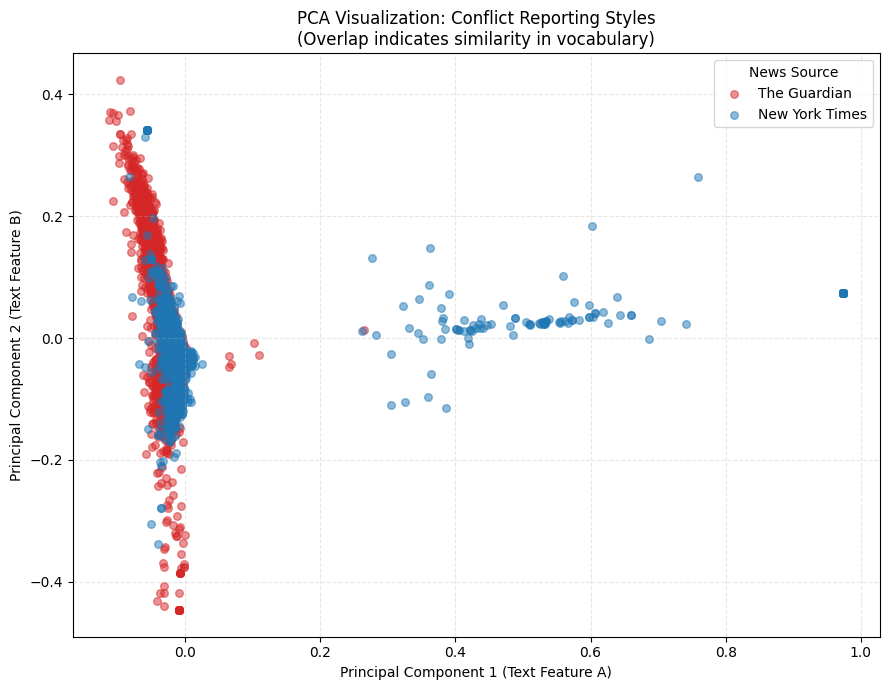

In [ ]:
# 4. Create the Plot
plt.figure(figsize=(9, 7))

# Plot points colored by Source
sources = q3_df['source'].unique()
colors = ['#d62728', '#1f77b4'] # Red for Guardian, Blue for NYT

for i, source in enumerate(sources):
    mask = q3_df['source'] == source
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], label=source, alpha=0.5, s=30, c=colors[i])

# Formatting
plt.title('PCA Visualization: Conflict Reporting Styles\n(Overlap indicates similarity in vocabulary)', fontsize=12)
plt.xlabel('Principal Component 1 (Text Feature A)')
plt.ylabel('Principal Component 2 (Text Feature B)')
plt.legend(title="News Source", loc='upper right')
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

As seen in the plot, the blue dots (NYT) and red dots (Guardian) largely occupy the same space.

This significant overlap indicates that there is NO distinct clustering pattern.

Therefore, we conclude that both sources use highly similar vocabulary and framing for global conflicts.